# Pretrain A/B/C **품질** 비교 (RMSE + 슬롯 분포 검증)

`compare_pretrain_ab.py` 노트북은 *속도/리소스* 만 비교합니다. 이 노트북은 그 자매편으로 **모델 정확도** (downstream RMSE) 를 비교하고, 동시에 "진짜로 augmentation 이 weighted 로 바뀌었는지" 를 슬롯 빈도 분포로 검증합니다.

비교 대상 (전부 ESOL 동일 시드/하이퍼파라미터, augmentation 정책만 다름):

| 측면 | aug_1 / aug_2 | views_fn | 슬롯 |
|---|---|---|---|
| **A** baseline | `MMFFrandom` / `MMFFrandom` | `RandomView` (원본 PyG 경로) | 사전 추출된 2개 균등; **pretrain p=5·finetune f=18·2-fold·1× 는 코드에서 고정** (budget 과 무관) |
| **B** top1+random | `MMFFweighted_top1` / `MMFFrandom` | `WeightedMMFFView` + `RandomView` | view1 = 가중치 **argmax** 슬롯; view2 = **균등 랜덤** MMFF 슬롯 쌍 |
| **C** weighted pair | `SIDE_C_AUG_2` (예: `top12`) | `WeightedMMFFView` 등 | **MMFF1..4** + `.pt` 가중치; C는 1등 vs 2등 슬롯 등 페어 설정 가능 |

**측면 선택 (`SIDES_SELECTION`)**: 셀 1에서 `('A','B','C')`, `'ABC'`, `'abc'`, `('b','c')` 처럼 **프리트레인·파인튠·모든 그래프**에 넣을 측면을 고릅니다. 내부적으로 대문자 `SIDES` 로 정규화됩니다.

각 셀은 독립적으로 다시 돌릴 수 있으며, 셀 1 의 **`QUALITY_BUDGET`** (`smoke` 기본 ≈전체 5분 전후 on GPU/XPU, `two_hour`, `max_accuracy`)·`BATCH_SIZE` 등으로 시간 ↔ 정확도를 조절합니다. 레거시로 `QUALITY_SMOKE=True` 이면 자동으로 `smoke` 와 동일합니다.

프리트레인 체크포인트는 각 측면별 **별도 폴더** (`./models/quality_<ts>/A`, `B`, `C` 등 `SIDES`) 에 저장됩니다. PNG / JSON 은 `figs/pretrain_quality_<MMDD_HHMM>/` 에 들어갑니다.

In [1]:
# --- 1. Setup ---------------------------------------------------------------
import os, sys, json, time, gc
from datetime import datetime
from pathlib import Path

NB_DIR = Path.cwd()
# 노트북 launcher 의 CWD 가 어디든 repo root 로 정렬.
REPO_ROOT = NB_DIR
for _p in [NB_DIR, *NB_DIR.parents]:
    if (_p / 'dig').is_dir() and (_p / 'examples').is_dir():
        REPO_ROOT = _p
        break
os.chdir(REPO_ROOT)
for p in [REPO_ROOT, REPO_ROOT / 'examples' / 'sslgraph' / 'bench']:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import numpy as np
import matplotlib.pyplot as plt
import torch
from dig.sslgraph.utils.device import pick_torch_device
import pretrain_quality_core as q

FIG_TS = datetime.now().strftime('%m%d_%H%M')
RUN_DIR = REPO_ROOT / 'examples' / 'sslgraph' / 'bench' / 'figs' / f'pretrain_quality_{FIG_TS}'
RUN_DIR.mkdir(parents=True, exist_ok=True)
MODEL_ROOT = REPO_ROOT / 'models' / f'quality_{FIG_TS}'
MODEL_ROOT.mkdir(parents=True, exist_ok=True)

DEVICE = pick_torch_device()
print('device:', DEVICE)
print('run dir:', RUN_DIR)
print('models  :', MODEL_ROOT)

# ===== 사용자가 자주 만지는 노브 =================================================
# P_EPOCH / F_EPOCH / N_FOLDS / N_TIMES / DIST_* / PRETRAIN_ENCODER 는 아래 QUALITY_BUDGET 에서 설정.
DATASET        = 'esol'      # pretrain + finetune 공통
DATASET_ROOT   = REPO_ROOT / 'dataset'   # ESOL 등 MoleculeNet; QM7/8은 ESOL_FILTER_QM78=True 일 때만
ESOL_FILTER_QM78 = False  # False(기본): full ESOL, QM7/QM8 processed 불필요. True: QM7∪QM8 교집합.
ESOL_TEST_MAX_ATOMS = 14  # None 이면 test 전체. 지정 시 finetune RMSE 는 **원자 개수(수소 포함) ≤ 이 값**인 test 분자만 (RDKit AddHs+GetNumAtoms, ESOL 그래프와 동일 스킴).
BATCH_SIZE     = 400
FINETUNE_BATCH = 128         # finetune.ipynb 기본 32 → 128 (XPU 점유율 ↑, ~2-3× 빠름)
WEIGHT_KT     = 0.5       # softmax 온도. atomization(기본)은 conformer 차이 크므로 0.5 권장; homolumo 는 0.3.
WEIGHT_MODE   = 'auto'    # 'explicit' / 'energy' / 'auto'
WEIGHT_NORM   = 'zscore'  # 'none' / 'zscore' / 'rank'. QDF 출력 차이가 작으므로 zscore 권장.
WEIGHT_SOURCE = 'qdf'     # 'qdf' (CSV 기반) or 'boltzmann' (에너지 기반)
QDF_PROPERTY  = 'atomization'  # ESOL: conformer 민감·QDF 활용 극대화(권장). homolumo 는 ESOL OOD·gap 작음.
                               # 'homolumo'    (비교용; rotamer 간 QDF 차이 매우 작음)
QDF_CHECKPOINT = None     # None = qdf_mmff_predict.py 의 preset 사용
                          # 다른 ckpt 시도 시 절대/상대 경로 입력
SCORE_EXPR    = None      # None = property 의 default
                          #   atomization → '-energy' (더 음수 = 더 안정 = 더 높은 점수)
                          #   homolumo    → 'gap' (= LUMO−HOMO, 갭 클수록 높은 점수)
WEIGHT_FALLBACK = 'boltzmann'  # QDF가 cover 못한 분자 처리. 'boltzmann' 권장.
                               # 'boltzmann' = MMFF 에너지 기반 Boltzmann (커버리지 100%)
                               # 'uniform'   = 0.25 균등 (= side A 와 동일)
                               # 'skip'      = .pt 에 빠뜨림 → view 가 균등 fallback
QDF_PRED_CSV = REPO_ROOT / 'dataset' / f'esol_qdf_mmff_preds_{QDF_PROPERTY}.csv'
WEIGHTS_PT   = REPO_ROOT / 'dataset' / f'esol_mmff_weights_qdf_{QDF_PROPERTY}.pt'

# 프리트레인 / 파인튠 / 모든 그래프에 포함할 측면 (비어 있지 않은 {'A','B','C'} 부분집합).
# 예: ('A', 'B', 'C'), 'ABC', 'abc', ['a', 'c'], ('B',).  set 은 순서가 불안정하므로 비권장.
_SIDES_CANON = ('A', 'B', 'C')


def _normalize_sides_selection(sel):
    if sel is None:
        return _SIDES_CANON
    items = []
    if isinstance(sel, str):
        for tok in sel.replace(',', ' ').split():
            ch = tok.strip().upper()
            if not ch:
                continue
            if len(ch) != 1 or ch not in 'ABC':
                raise ValueError(
                    f'SIDES_SELECTION token {tok!r} invalid; use letters A, B, C only '
                    f"(e.g. 'ABC' or 'A, C')."
                )
            items.append(ch)
    elif isinstance(sel, (tuple, list, set, frozenset)):
        for x in sel:
            s = str(x).strip().upper()
            if len(s) != 1 or s not in 'ABC':
                raise ValueError(
                    f'SIDES_SELECTION entry {x!r} → {s!r}; expected one of A, B, C.'
                )
            items.append(s)
    else:
        raise TypeError(
            f'SIDES_SELECTION must be str, tuple, list, or set; got {type(sel).__name__}'
        )
    seen = set()
    out = []
    for s in items:
        if s not in seen:
            seen.add(s)
            out.append(s)
    if not out:
        raise ValueError('SIDES_SELECTION resolved to an empty tuple')
    return tuple(out)


SIDES_SELECTION = ('A', 'B', 'C')
SIDES = _normalize_sides_selection(SIDES_SELECTION)
# 전체 파이프라인 목표: two_hour ≈ 2h (가중치·ESOL processed 캐시, GPU/XPU 가정; CPU는 더 걸릴 수 있음).
QUALITY_BUDGET = 'two_hour'  # 'two_hour' | 'max_accuracy' | 'smoke'
QUALITY_SMOKE = False  # True 이면 예전 노트북 호환으로 smoke 과 동일하게 강제.
_qb_ok = {'two_hour', 'max_accuracy', 'smoke'}
if QUALITY_SMOKE:
    QUALITY_BUDGET = 'smoke'
else:
    QUALITY_BUDGET = str(QUALITY_BUDGET).strip().lower()
    if QUALITY_BUDGET not in _qb_ok:
        raise ValueError(
            f'QUALITY_BUDGET must be one of {sorted(_qb_ok)}, got {QUALITY_BUDGET!r}'
        )
colors = {'A': '#7f7f7f', 'B': '#1f77b4', 'C': '#d62728'}
labels = {
    'A': 'A baseline (RandomView)',
    'B': 'B top1 + MMFFrandom',
    'C': 'C weighted (top1 vs top2)',
}

# --- epoch wall-time (DataLoader + mixed-precision forward) -----------------
# ESOL 은 epoch 당 배치 수가 적어서(≈3 @400) GPU/XPU 커널이 병목인 경우가 많습니다.
PRETRAIN_NUM_WORKERS = 8   # Linux: 8 권장. Windows+RDKit worker 오류 시 0.
PRETRAIN_PIN_MEMORY = True  # GPU/XPU 시 True 권장. 문제 시 False.
PRETRAIN_AMP = True         # CUDA/XPU에서 속도↑(CPU면 무시). 문제 시 False.
if DEVICE.type == 'cpu' and PRETRAIN_PIN_MEMORY:
    PRETRAIN_PIN_MEMORY = False  # pin_memory 는 GPU/XPU 전용; CPU 에서 경고·이슈 방지.

# --- 진단 순서 (A → B → C): cutoff, side-C view-2, 백본 --------------------
# (A) SchNet cutoff 축소: 국소 RBF가 conformers 차이에 더 민감해지도록.
PRETRAIN_CUTOFF = 3.0
# (C) Side C 의 view 페어 선택 방식.
#   "top1"         — 양쪽 view 모두 1등(argmax) 슬롯만. 2등은 계산도 안 함.
#                    positive pair = 같은 좌표 두 번. augmentation=identity
#                    ablation.
#   "top12"        — (1등, 2등) 결정적 짝. 두 view 가 같은 그래프에서 항상
#                    가장 가중치 높은 / 두 번째 슬롯을 가져옵니다.
#   "noise"        — view1=MMFFweighted, view2=NodeTranslation(noise) (약함)
#   "MMFFweighted" — 레거시(양쪽 모두 가중 i.i.d. 샘플)
SIDE_C_AUG_2 = "top12"   # Side C: 1등 vs 2등 슬롯 (결정적). 스모크/본실험 공통 권장.

if QUALITY_BUDGET == 'smoke':
    # 목표: GPU/XPU 기준 전체(가중치·분포·pretrain×SIDES·finetune×SIDES) ~5분 전후. CPU·메모리 부족 시 P/F/DIST 를 줄이세요.
    P_EPOCH, F_EPOCH = 7, 26
    N_FOLDS, N_TIMES = 2, 1
    DIST_N_CALLS, DIST_BATCH = 40, 160
    PRETRAIN_ENCODER = 'gin'
elif QUALITY_BUDGET == 'two_hour':
    # pretrain+finetune+슬롯검증 합산 ~2h 목표 (max_accuracy 대비 ~20× 수준으로 epoch×fold×times 축소).
    P_EPOCH, F_EPOCH = 36, 80
    N_FOLDS, N_TIMES = 3, 2
    DIST_N_CALLS, DIST_BATCH = 24, 192
    PRETRAIN_ENCODER = 'schnet'
else:  # max_accuracy — overnight class
    P_EPOCH, F_EPOCH = 200, 400
    N_FOLDS, N_TIMES = 5, 7
    DIST_N_CALLS, DIST_BATCH = 50, 256
    PRETRAIN_ENCODER = 'spherenet'

os.environ['DATALOADER_NUM_WORKERS'] = str(int(PRETRAIN_NUM_WORKERS))
if PRETRAIN_PIN_MEMORY:
    os.environ['PIN_MEMORY'] = '1'
else:
    os.environ.pop('PIN_MEMORY', None)
# ============================================================================
# 측면 A: ``pretrain_quality_core`` 가 pretrain ``p_epoch=5``, finetune ``f_epoch=18``,
# ``n_folds=2``, ``n_times=1`` 로 고정합니다. B/C 만 ``QUALITY_BUDGET`` 의 ``P_EPOCH``/``F_EPOCH`` 등을 따릅니다.

print({
    'DATASET': DATASET, 'BATCH_SIZE': BATCH_SIZE,
    'SIDES_SELECTION': SIDES_SELECTION,
    'SIDES': SIDES, 'QUALITY_BUDGET': QUALITY_BUDGET, 'QUALITY_SMOKE': QUALITY_SMOKE,
    'P_EPOCH': P_EPOCH, 'F_EPOCH': F_EPOCH,
    'N_TIMES': N_TIMES, 'N_FOLDS': N_FOLDS,
    'WEIGHT_KT': WEIGHT_KT, 'WEIGHT_MODE': WEIGHT_MODE,
    'WEIGHT_NORM': WEIGHT_NORM, 'WEIGHT_SOURCE': WEIGHT_SOURCE,
    'QDF_PROPERTY': QDF_PROPERTY, 'QDF_PRED_CSV': QDF_PRED_CSV.name,
    'WEIGHTS_PT': WEIGHTS_PT.name,
    'DIST_N_CALLS': DIST_N_CALLS, 'DIST_BATCH': DIST_BATCH,
    'PRETRAIN_NUM_WORKERS': PRETRAIN_NUM_WORKERS,
    'PRETRAIN_PIN_MEMORY': PRETRAIN_PIN_MEMORY,
    'PRETRAIN_AMP': PRETRAIN_AMP,
    'PRETRAIN_CUTOFF': PRETRAIN_CUTOFF,
    'SIDE_C_AUG_2': SIDE_C_AUG_2,
    'PRETRAIN_ENCODER': PRETRAIN_ENCODER,
    'DATASET_ROOT': str(DATASET_ROOT),
    'ESOL_FILTER_QM78': ESOL_FILTER_QM78,
    'ESOL_TEST_MAX_ATOMS': ESOL_TEST_MAX_ATOMS,
})

device: cpu
run dir: /home/ubuntu/3DGCL/examples/sslgraph/bench/figs/pretrain_quality_0514_0729
models  : /home/ubuntu/3DGCL/models/quality_0514_0729
{'DATASET': 'esol', 'BATCH_SIZE': 400, 'SIDES_SELECTION': ('A', 'B', 'C'), 'SIDES': ('A', 'B', 'C'), 'QUALITY_BUDGET': 'two_hour', 'QUALITY_SMOKE': False, 'P_EPOCH': 36, 'F_EPOCH': 80, 'N_TIMES': 2, 'N_FOLDS': 3, 'WEIGHT_KT': 0.5, 'WEIGHT_MODE': 'auto', 'WEIGHT_NORM': 'zscore', 'WEIGHT_SOURCE': 'qdf', 'QDF_PROPERTY': 'atomization', 'QDF_PRED_CSV': 'esol_qdf_mmff_preds_atomization.csv', 'WEIGHTS_PT': 'esol_mmff_weights_qdf_atomization.pt', 'DIST_N_CALLS': 24, 'DIST_BATCH': 192, 'PRETRAIN_NUM_WORKERS': 8, 'PRETRAIN_PIN_MEMORY': False, 'PRETRAIN_AMP': True, 'PRETRAIN_CUTOFF': 3.0, 'SIDE_C_AUG_2': 'top12', 'PRETRAIN_ENCODER': 'schnet', 'DATASET_ROOT': '/home/ubuntu/3DGCL/dataset', 'ESOL_FILTER_QM78': False, 'ESOL_TEST_MAX_ATOMS': 14}


## 1. weights 파일 준비

**C** 측면을 돌리려면 `MMFF_WEIGHTS_PATH` (per-graph slot weights `.pt`) 가 필요합니다. (A는 불필요)

| `WEIGHT_SOURCE` | `QDF_PROPERTY` | CSV columns | 의미 | 권장 사용처 |
|---|---|---|---|---|
| `qdf` | `atomization` | `smiles,slot,energy` | softmax(z-score(−energy)/kT) — **conformer 별로 큰 차이**, ESOL/큰 분자에 강함 | **현재 기본값** |
| `qdf` | `homolumo` | `smiles,slot,homo,lumo` | softmax(z-score((LUMO−HOMO))/kT) 기본 `gap`; rotamer 간 ~meV | 비교/회귀 분석용 |
| `boltzmann` | — | (CSV 없이 MMFF energy) | softmax(-(E_k - E_min)/kT) | QDF 모델이 사용 불가일 때 |

체크포인트 선택은 `qdf_mmff_predict.py` 가 `--qdf-property` 의 **preset** 으로 자동 결정합니다.
다른 ckpt 를 시도하려면 setup 셀의 `QDF_CHECKPOINT` 에 경로를 넣으세요.

| `QDF_PROPERTY` | preset checkpoint |
|---|---|
| `atomization` | `output/model--QM9under14atoms_atomizationenergy_eV--6-31G--…--dim250--hidden_HK250--sum--batch_size4--iteration2000` |
| `homolumo`    | `output/model--QM9under7atoms_homolumo_eV--6-31G--…--dim200--hidden_HK200--mean--batch_size8--iteration2000` |

이미 `dataset/esol_mmff_weights_qdf_<property>.pt` 가 있으면 캐시를 씁니다. 다만 **디스크에 저장된 `kT` 가 셀 1 의 `WEIGHT_KT` 와 다르면** (가중치 첨예화 변경 시) 자동으로 `compute_mmff_weights.py` 를 다시 돌려 `.pt` 를 갱신합니다.

## 1b. QDF 앙상블 · GraphCL 보조 (선택)

**앙상블 MMFF 가중치** — `compute_mmff_weights.py`에 `--pred-csv`를 **여러 번** 주면, (SMILES, slot)마다 `mean`/`median`으로 합친 뒤 기존과 같이 softmax `.pt`를 만듭니다. 네 슬롯이 **모든 CSV에** 있는 분자만 교집합에 포함됩니다. 생성된 `WEIGHTS_PT`는 **B / C** 가중 뷰에만 쓰이며, **A는 사용하지 않습니다.**

**QDF가 DGCL(GraphCL)을 보조** — `build_qdf_aux_ensemble.py`로 분자별 스칼라 타깃 `.pt`를 만들고, pretrain 시 `loss += QDF_AUX_LAMBDA * MSE(Linear(z), target)` 을 **B / C에만** 넣습니다. **측면 A는 항상 초기 GraphCL 베이스라인**(QDF 보조·앙상블 가중치 없음)입니다 (`run_pretrain_side`에서 A일 때 `qdf_aux` 무시).

아래 코드 셀에서 `RUN_*` 플래그와 경로를 조절한 뒤 실행하세요.

In [2]:
# --- 1b (선택) QDF 앙상블 가중치 + QDF 보조 타깃 --------------------------------
import subprocess

# 측면 A 는 통제군(초기 GraphCL): MMFF 앙상블 `WEIGHTS_PT`·`QDF_AUX_*` 는 B/C 에만 반영됩니다.
# ensure-weights 셀보다 *앞*에서 돌릴 필요는 없음. 가중치를 앙상블로 다시 빌드한 뒤에는
# ensure-weights 셀을 한 번 더 실행해 메타/캐시를 맞추는 것을 권장합니다.

# ----- 앙상블 / 보조 타깃 (여기 값 조절) ------------------------------------
QDF_ENSEMBLE_REDUCE = 'mean'  # 'mean' | 'median'

# 두 번째 예측 CSV: `qdf_mmff_predict.py` 를 다른 ckpt 로 돌린 출력 등 (QDF_PRED_CSV 와 동일 스키마).
# 파일이 없으면 아래 로직이 **같은 CSV를 두 번** 넣어 `compute_mmff_weights` 의 앙상블 분기만 태움(가중치 수치는 단일과 동일).
QDF_WEIGHT_ENSEMBLE_EXTRA_CSV = [
    REPO_ROOT / 'dataset' / f'esol_qdf_mmff_preds_{QDF_PROPERTY}_run2.csv',
]

RUN_QDF_WEIGHT_ENSEMBLE = True  # WEIGHTS_PT 를 `--pred-csv` 2회 이상으로 재생성
RUN_BUILD_QDF_AUX = True          # 보조 타깃 .pt 생성
QDF_AUX_PT = REPO_ROOT / 'dataset' / f'esol_qdf_aux_{QDF_PROPERTY}.pt'
QDF_AUX_LAMBDA = 0.05             # >0 이고 .pt 가 있으면 pretrain 에 MSE 보조 전달


def _unique_qdf_pred_csvs() -> list[Path]:
    out: list[Path] = []
    seen: set[str] = set()
    for p in [QDF_PRED_CSV, *QDF_WEIGHT_ENSEMBLE_EXTRA_CSV]:
        pp = Path(p)
        if pp.is_file():
            k = str(pp.resolve())
            if k not in seen:
                seen.add(k)
                out.append(pp)
    return out


def _qdf_pred_csvs_for_mmff_weights() -> list[Path]:
    """compute_mmff_weights 는 pred-csv 가 2개 이상일 때만 앙상블 병합을 쓴다."""
    u = _unique_qdf_pred_csvs()
    if len(u) >= 2:
        return u
    if len(u) == 1:
        return [u[0], u[0]]
    return []


def _run_1b(cmd, **kw):
    print('$', ' '.join(str(c) for c in cmd))
    return subprocess.run([str(c) for c in cmd], check=True, **kw)


if RUN_BUILD_QDF_AUX:
    _aux_csvs = _unique_qdf_pred_csvs()
    if not _aux_csvs:
        print('[1b] aux 빌드 스킵: QDF 예측 CSV 없음 (셀 1 QDF_PRED_CSV / ensure-weights 확인).')
    else:
        cmd = [
            sys.executable,
            'examples/sslgraph/bench/build_qdf_aux_ensemble.py',
            '--out',
            str(QDF_AUX_PT),
            '--qdf-ensemble-reduce',
            QDF_ENSEMBLE_REDUCE,
        ]
        for pp in _aux_csvs:
            cmd.extend(['--pred-csv', str(pp)])
        _run_1b(cmd)

if RUN_QDF_WEIGHT_ENSEMBLE and WEIGHT_SOURCE == 'qdf':
    _w_csvs = _qdf_pred_csvs_for_mmff_weights()
    if len(_w_csvs) < 2:
        print('[1b] 가중치 앙상블 스킵: 유효한 QDF 예측 CSV 가 없음.')
    else:
        cmd = [
            sys.executable,
            'examples/sslgraph/bench/compute_mmff_weights.py',
            '--dataset',
            DATASET,
            '--source',
            'qdf',
            '--kT',
            str(WEIGHT_KT),
            '--normalize',
            WEIGHT_NORM,
            '--fallback',
            WEIGHT_FALLBACK,
            '--qdf-ensemble-reduce',
            QDF_ENSEMBLE_REDUCE,
            '--out',
            str(WEIGHTS_PT),
        ]
        if SCORE_EXPR:
            cmd += ['--score-expr', SCORE_EXPR]
        for pp in _w_csvs:
            cmd.extend(['--pred-csv', str(pp)])
        _run_1b(cmd)
        print('[1b] 앙상블 가중치 저장:', WEIGHTS_PT)
else:
    print('[1b] 가중치 앙상블 빌드 스킵.')

print(
    '[1b] QDF_AUX_LAMBDA=',
    QDF_AUX_LAMBDA,
    '  QDF_AUX_PT=',
    QDF_AUX_PT,
    '  exists=',
    QDF_AUX_PT.is_file(),
)

$ /home/ubuntu/3DGCL/.venv/bin/python examples/sslgraph/bench/build_qdf_aux_ensemble.py --out /home/ubuntu/3DGCL/dataset/esol_qdf_aux_atomization.pt --qdf-ensemble-reduce mean --pred-csv /home/ubuntu/3DGCL/dataset/esol_qdf_mmff_preds_atomization.csv
[qdf:ensemble:mean] merged 1 CSVs -> 731 molecules (SMILES with 4 slots in every file)
{
  "qdf_property": "atomization",
  "value_cols": [
    "energy"
  ],
  "scalar": "energy",
  "ensemble_reduce": "mean",
  "n_csv": 1,
  "n_molecules": 731,
  "pred_csv": [
    "/home/ubuntu/3DGCL/dataset/esol_qdf_mmff_preds_atomization.csv"
  ]
}
[saved] /home/ubuntu/3DGCL/dataset/esol_qdf_aux_atomization.pt
$ /home/ubuntu/3DGCL/.venv/bin/python examples/sslgraph/bench/compute_mmff_weights.py --dataset esol --source qdf --kT 0.5 --normalize zscore --fallback boltzmann --qdf-ensemble-reduce mean --out /home/ubuntu/3DGCL/dataset/esol_mmff_weights_qdf_atomization.pt --pred-csv /home/ubuntu/3DGCL/dataset/esol_qdf_mmff_preds_atomization.csv --pred-csv /home/

In [3]:
# --- 2. Ensure weights .pt --------------------------------------------------
import subprocess

PY = sys.executable

def _run(cmd, **kw):
    print('$', ' '.join(str(c) for c in cmd))
    return subprocess.run([str(c) for c in cmd], check=True, **kw)

def _load_weights_pt(path):
    try:
        return torch.load(path, map_location='cpu', weights_only=False)
    except TypeError:
        return torch.load(path, map_location='cpu')

_rebuild_weights = not WEIGHTS_PT.is_file()
if WEIGHTS_PT.is_file():
    _w0 = _load_weights_pt(WEIGHTS_PT)
    _disk_kt = float(_w0.get('kT', float('nan')))
    _disk_fb = _w0.get('fallback')
    _disk_fb_policy = _disk_fb.get('policy') if isinstance(_disk_fb, dict) else None
    if abs(_disk_kt - float(WEIGHT_KT)) > 1e-6:
        print('[info] on-disk kT', _disk_kt, '!= WEIGHT_KT', WEIGHT_KT,
              '— recomputing .pt so softmax temperature (D) matches setup.')
        _rebuild_weights = True
    elif WEIGHT_SOURCE == 'qdf' and _disk_fb_policy != WEIGHT_FALLBACK:
        print('[info] on-disk fallback', _disk_fb_policy, '!= WEIGHT_FALLBACK',
              WEIGHT_FALLBACK, '— recomputing so QDF-uncovered molecules use the new policy.')
        _rebuild_weights = True
    elif WEIGHT_SOURCE == 'qdf':
        try:
            _want_se = q.desired_qdf_score_expr(QDF_PROPERTY, SCORE_EXPR)
            _disk_se = str(_w0.get('score_expr', ''))
            if _disk_se.replace(' ', '') != _want_se.replace(' ', ''):
                print('[info] on-disk score_expr', repr(_disk_se), '!= desired',
                      repr(_want_se), '— recomputing .pt.')
                _rebuild_weights = True
        except Exception as _e:
            print('[warn] score_expr cache check skipped:', _e)

if _rebuild_weights:
    if WEIGHT_SOURCE == 'qdf':
        if not QDF_PRED_CSV.is_file():
            print(f'[info] running qdf_mmff_predict.py ({QDF_PROPERTY}) — this is slow.')
            pred_cmd = [PY, 'examples/sslgraph/bench/qdf_mmff_predict.py',
                        '--dataset', DATASET,
                        '--qdf-property', QDF_PROPERTY,
                        '--out', QDF_PRED_CSV]
            if QDF_CHECKPOINT:
                pred_cmd += ['--checkpoint', str(QDF_CHECKPOINT)]
            _run(pred_cmd)
        weights_cmd = [PY, 'examples/sslgraph/bench/compute_mmff_weights.py',
                       '--dataset', DATASET, '--source', 'qdf',
                       '--pred-csv', QDF_PRED_CSV,
                       '--kT', WEIGHT_KT,
                       '--normalize', WEIGHT_NORM,
                       '--fallback', WEIGHT_FALLBACK,
                       '--out', WEIGHTS_PT]
        if SCORE_EXPR:
            weights_cmd += ['--score-expr', SCORE_EXPR]
        _run(weights_cmd)
    else:
        _run([PY, 'examples/sslgraph/bench/compute_mmff_weights.py',
              '--dataset', DATASET, '--source', 'boltzmann',
              '--kT', WEIGHT_KT,
              '--out', WEIGHTS_PT])

print('weights file:', WEIGHTS_PT, 'exists=', WEIGHTS_PT.is_file())
if WEIGHTS_PT.is_file():
    meta = _load_weights_pt(WEIGHTS_PT)
    print('  meta:', {k: meta.get(k) for k in ('source', 'kT', 'qdf_property',
                                                'score_expr', 'normalize')})
    print('  fallback:', meta.get('fallback'))
    print('  n_smiles in weights file:', len(meta.get('weights', {})))

    # Coverage check vs the actual ESOL dataset. WeightedMMFFView falls back to
    # uniform sampling for SMILES without weights → these molecules behave
    # like side A. If coverage is far below 100%, the A vs C signal is
    # diluted proportionally and small-sample noise can flip the comparison.
    try:
        from dig.threedgraph.dataset import MoleculeNet
        if DATASET == 'esol' and ESOL_FILTER_QM78:
            _ds, _cov_f = q.molnet_esol_qm78_subset(root=DATASET_ROOT, seed=2222)
        else:
            _ds = MoleculeNet(root=str(DATASET_ROOT), name=DATASET)
        _smiles = set(meta.get('weights', {}).keys())
        _n_total = len(_ds)
        _n_cov = sum(1 for d in _ds if getattr(d, 'smiles', None) in _smiles)
        _cov = _n_cov / max(_n_total, 1)
        _fb_meta = meta.get('fallback') or {}
        _fb_pol = _fb_meta.get('policy') if isinstance(_fb_meta, dict) else None
        _n_boltz = int(_fb_meta.get('n_added', 0)) if isinstance(_fb_meta, dict) else 0
        _n_uni = int(_fb_meta.get('n_uniform', 0)) if isinstance(_fb_meta, dict) else 0
        _n_qdf = max(_n_cov - _n_boltz - _n_uni, 0)
        print(f'  coverage: {_n_cov}/{_n_total} ({_cov*100:.1f}%)  '
              f'[QDF~{_n_qdf}, boltzmann_fallback={_n_boltz}, uniform={_n_uni}]')
        if _cov < 0.9:
            print(f'  ⚠ coverage < 90%: 비-가중치 분자가 view 단계에서 uniform 으로 fallback 됩니다. '
                  "WEIGHT_FALLBACK='boltzmann' 으로 다시 빌드하면 P/S/Cl/Br/I 분자도 "
                  'MMFF 에너지 기반 가중치를 받습니다.')
        elif _fb_pol == 'boltzmann' and _n_boltz > 0:
            print(f'  ✓ QDF-uncovered {_n_boltz} 분자는 MMFF 에너지 Boltzmann 으로 채워졌습니다.')
    except Exception as _e:
        print('  (coverage check skipped:', _e, ')')

weights file: /home/ubuntu/3DGCL/dataset/esol_mmff_weights_qdf_atomization.pt exists= True
  meta: {'source': 'qdf', 'kT': 0.5, 'qdf_property': 'atomization', 'score_expr': '-energy', 'normalize': 'zscore'}
  fallback: {'policy': 'boltzmann', 'n_added': 392, 'n_uniform': 0, 'n_total': 1128}
  n_smiles in weights file: 1123
  coverage: 916/1128 (81.2%)  [QDF~524, boltzmann_fallback=392, uniform=0]
  ⚠ coverage < 90%: 비-가중치 분자가 view 단계에서 uniform 으로 fallback 됩니다. WEIGHT_FALLBACK='boltzmann' 으로 다시 빌드하면 P/S/Cl/Br/I 분자도 MMFF 에너지 기반 가중치를 받습니다.


## 2. 슬롯 분포 검증 — "진짜 랜덤이 바뀌었나?"

각 측면마다 GraphCL 의 첫 배치에 대해 **라운드를 `DIST_N_CALLS` 번** 반복합니다. 라운드마다 **aug_1(view1)** 과 **aug_2(view2)** 를 각각 한 번 호출하고, 두 뷰에서 나온 MMFF 슬롯 (1..4) 선택을 **하나의 분포로 합산**합니다 (뷰 호출 ≈ `2 × DIST_N_CALLS` × 그래프 수). 반환값·`slot_distribution.json` 에는 `view0`·`view1` 키로 aug1·aug2 **각각**의 `slot_freq`·KL·entropy 가 따로 들어 있습니다. 일치 판정은 `out.pos` 와 `batch.max{k}pos_mmff` 의 정확 비교 (atol=1e-5).

기대값:
* **A**  — `random.sample` 이 `aug_1/aug_2` 초기화 시 미리 고른 **2개 슬롯에만** 표가 몰린다 (≈50:50, 나머지 0).
* **C**  — MMFF1..4 **4개 슬롯 전체** 사용. KL(observed‖uniform) 와 per-graph entropy 가 A 와 다르다.

In [4]:
# --- 3. Slot distribution check --------------------------------------------
dist_results = {}
for side in SIDES:
    kw = dict(
        dataset=DATASET, batch_size=DIST_BATCH,
        n_calls=DIST_N_CALLS, device=DEVICE,
        weight_kT=WEIGHT_KT, weight_mode=WEIGHT_MODE,
        weight_norm=WEIGHT_NORM,
        p_pretrain_amp=PRETRAIN_AMP,
                encoder=PRETRAIN_ENCODER,
        cutoff=PRETRAIN_CUTOFF,
        side_c_aug_2=SIDE_C_AUG_2,
        esol_filter_qm78=ESOL_FILTER_QM78,
        dataset_root=DATASET_ROOT,
    )
    if side in ('B', 'C'):
        kw['weights_path'] = WEIGHTS_PT
    t0 = time.perf_counter()
    res = q.measure_slot_distribution(side, **kw)
    res['elapsed_s'] = time.perf_counter() - t0
    dist_results[side] = res
    v0, v1 = res['view_classes']
    print(f"[{side}] {res['view_class']}")
    print(f"  pooled  slots={res['slot_freq']} "
          f"KL={res['kl_to_uniform_bits']:.3f}b  H̄={res['per_graph_entropy_bits_mean']:.3f}b")
    print(f"  view0 ({v0}) slots={res['view0']['slot_freq']} "
          f"KL={res['view0']['kl_to_uniform_bits']:.3f}b  H̄={res['view0']['per_graph_entropy_bits_mean']:.3f}b")
    print(f"  view1 ({v1}) slots={res['view1']['slot_freq']} "
          f"KL={res['view1']['kl_to_uniform_bits']:.3f}b  H̄={res['view1']['per_graph_entropy_bits_mean']:.3f}b")

with open(RUN_DIR / 'slot_distribution.json', 'w', encoding='utf-8') as f:
    json.dump(dist_results, f, indent=2)
print('saved:', RUN_DIR / 'slot_distribution.json')

[A] RandomView+RandomView
  pooled  slots=[0.2556423611111111, 0.24793836805555555, 0.0, 0.4964192708333333] KL=0.497b  H̄=1.482b
  view0 (RandomView) slots=[0.0, 0.4958767361111111, 0.0, 0.5041232638888888] KL=1.000b  H̄=0.972b
  view1 (RandomView) slots=[0.5112847222222222, 0.0, 0.0, 0.4887152777777778] KL=1.000b  H̄=0.972b
[B] WeightedMMFFView+RandomView
  pooled  slots=[0.15625, 0.3394097222222222, 0.08854166666666667, 0.4157986111111111] KL=0.216b  H̄=1.136b
  view0 (WeightedMMFFView) slots=[0.3125, 0.171875, 0.17708333333333334, 0.3385416666666667] KL=0.068b  H̄=-0.000b
  view1 (RandomView) slots=[0.0, 0.5069444444444444, 0.0, 0.4930555555555556] KL=1.000b  H̄=0.969b
[C] WeightedMMFFView+WeightedMMFFView
  pooled  slots=[0.2421875, 0.16927083333333334, 0.2265625, 0.3619791666666667] KL=0.055b  H̄=1.000b
  view0 (WeightedMMFFView) slots=[0.3125, 0.171875, 0.17708333333333334, 0.3385416666666667] KL=0.068b  H̄=-0.000b
  view1 (WeightedMMFFView) slots=[0.171875, 0.16666666666666666,

saved: /home/ubuntu/3DGCL/examples/sslgraph/bench/figs/pretrain_quality_0514_0729/slot_distribution_0514_0729.png


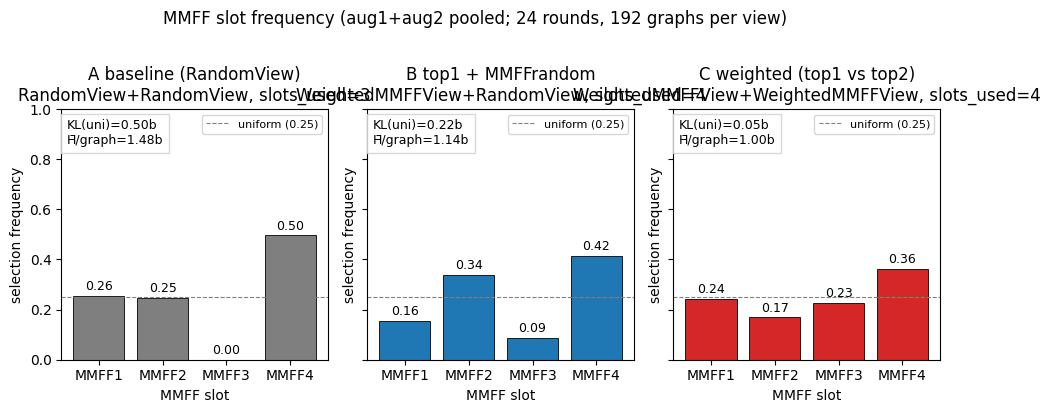

In [5]:
# --- 4. Slot distribution plot ---------------------------------------------
_n = len(SIDES)
fig, axes = plt.subplots(1, _n, figsize=(3.2 * _n, 4.0), sharey=True)
if _n == 1:
    axes = [axes]
for ax, side in zip(axes, SIDES):
    r = dist_results[side]
    bars = ax.bar(['MMFF1', 'MMFF2', 'MMFF3', 'MMFF4'], r['slot_freq'],
                  color=colors[side], edgecolor='black', linewidth=0.6)
    ax.axhline(0.25, color='gray', linestyle='--', linewidth=0.8,
               label='uniform (0.25)')
    ax.set_ylim(0, 1.0)
    ax.set_title(f"{labels[side]}\n{r['view_class']}, slots_used={r['n_slots_used']}")
    ax.set_xlabel('MMFF slot')
    ax.set_ylabel('selection frequency')
    ax.bar_label(bars, fmt='%.2f', padding=2, fontsize=9)
    ax.text(0.02, 0.96,
            f"KL(uni)={r['kl_to_uniform_bits']:.2f}b\nH̄/graph={r['per_graph_entropy_bits_mean']:.2f}b",
            transform=ax.transAxes, ha='left', va='top', fontsize=9,
            bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray'))
    ax.legend(loc='upper right', fontsize=8)

plt.suptitle(
    f'MMFF slot frequency (aug1+aug2 pooled; {DIST_N_CALLS} rounds, '
    f'{DIST_BATCH} graphs per view)', y=1.02, fontsize=12)
plt.tight_layout()
out = RUN_DIR / f'slot_distribution_{FIG_TS}.png'
fig.savefig(out, dpi=140, bbox_inches='tight')
print('saved:', out)
plt.show()

## 3. 전체 Pretrain (A / B / C)

동일한 시드/하이퍼파라미터로 GraphCL 프리트레인을 **측면마다 한 번씩** 돌립니다 (`SIDES` 개수만큼, 각각 별도 폴더). 각 epoch loss 를 캡처해 곡선으로 그립니다.

In [6]:
# --- 5. Run full pretrain for each side -------------------------------------
pre_results = {}
for side in SIDES:
    root = MODEL_ROOT / side
    root.mkdir(parents=True, exist_ok=True)
    kw = dict(
        dataset=DATASET, batch_size=BATCH_SIZE,
        p_epoch=P_EPOCH, model_root=root, device=DEVICE,
        weight_kT=WEIGHT_KT, weight_mode=WEIGHT_MODE,
        weight_norm=WEIGHT_NORM,
        p_pretrain_amp=PRETRAIN_AMP,
                encoder=PRETRAIN_ENCODER,
        cutoff=PRETRAIN_CUTOFF,
        side_c_aug_2=SIDE_C_AUG_2,
        esol_filter_qm78=ESOL_FILTER_QM78,
        dataset_root=DATASET_ROOT,
    )
    if side != 'A':
        _qdf_l = float(globals().get('QDF_AUX_LAMBDA', 0) or 0)
        _qdf_p = globals().get('QDF_AUX_PT')
        if _qdf_l > 0 and _qdf_p is not None and Path(_qdf_p).is_file():
            kw['qdf_aux_lambda'] = _qdf_l
            kw['qdf_aux_pt'] = Path(_qdf_p)
    if side in ('B', 'C'):
        kw['weights_path'] = WEIGHTS_PT
    print(f'\n===== pretrain side {side} =====')
    res = q.run_pretrain_side(side, **kw)
    pre_results[side] = res
    print(f"  view={res['view_classes']} wall={res['wall_s']:.1f}s")
    print(f"  best_ckpt={res['best_ckpt']}")
    if res['losses_per_epoch']:
        print(f"  losses: first={res['losses_per_epoch'][0]:.3f}  last={res['losses_per_epoch'][-1]:.3f}")
    gc.collect()
    if hasattr(torch, 'xpu'):
        try: torch.xpu.empty_cache()
        except Exception: pass

with open(RUN_DIR / 'pretrain_summary.json', 'w', encoding='utf-8') as f:
    json.dump(pre_results, f, indent=2, default=str)
print('\nsaved:', RUN_DIR / 'pretrain_summary.json')


===== pretrain side A =====


/home/ubuntu/3DGCL/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Pretraining: epoch 1:   0%|          | 0/5 [00:00<?, ?it/s]

/home/ubuntu/3DGCL/models/quality_0514_0729/A/encoder-schnet_pretrain-esol_batch-400_proj-schnet_cutoff-3.0_layers-2_filter-128_gau-50_z_dim-32_lr-0.001_aug_1-MMFFrandom_aug_2-MMFFrandom_aug_ratio-0.25_tau-0.2_optim-ExponentialLR_weight_decay-0_expo_gamma-0.95_dropout-0.0


Pretraining: epoch 5: 100%|██████████| 5/5 [00:32<00:00,  6.57s/it, loss=12.9868]


  view=['RandomView', 'RandomView'] wall=33.3s
  best_ckpt=/home/ubuntu/3DGCL/models/quality_0514_0729/A/encoder-schnet_pretrain-esol_batch-400_proj-schnet_cutoff-3.0_layers-2_filter-128_gau-50_z_dim-32_lr-0.001_aug_1-MMFFrandom_aug_2-MMFFrandom_aug_ratio-0.25_tau-0.2_optim-ExponentialLR_weight_decay-0_expo_gamma-0.95_dropout-0.0/enc_best_epoch-5_loss-12.987.pkl
  losses: first=16.861  last=12.987

===== pretrain side B =====


...

  view=['WeightedMMFFView', 'RandomView'] wall=298.4s
  best_ckpt=/home/ubuntu/3DGCL/models/quality_0514_0729/B/encoder-schnet_pretrain-esol_batch-400_proj-schnet_cutoff-3.0_layers-2_filter-128_gau-50_z_dim-32_lr-0.001_aug_1-MMFFweighted_top1_aug_2-MMFFrandom_aug_ratio-0.25_tau-0.2_optim-ExponentialLR_weight_decay-0_expo_gamma-0.95_dropout-0.0/enc_best_epoch-35_loss-111.456.pkl
  losses: first=2858.819  last=111.739

===== pretrain side C =====


Pretraining: epoch 1:   0%|          | 0/36 [00:00<?, ?it/s]

/home/ubuntu/3DGCL/models/quality_0514_0729/C/encoder-schnet_pretrain-esol_batch-400_proj-schnet_cutoff-3.0_layers-2_filter-128_gau-50_z_dim-32_lr-0.001_aug_1-MMFFweighted_top1_aug_2-MMFFweighted_top2_aug_ratio-0.25_tau-0.2_optim-ExponentialLR_weight_decay-0_expo_gamma-0.95_dropout-0.0


Pretraining: epoch 36: 100%|██████████| 36/36 [04:28<00:00,  7.47s/it, loss=111.7390] 


  view=['WeightedMMFFView', 'WeightedMMFFView'] wall=269.5s
  best_ckpt=/home/ubuntu/3DGCL/models/quality_0514_0729/C/encoder-schnet_pretrain-esol_batch-400_proj-schnet_cutoff-3.0_layers-2_filter-128_gau-50_z_dim-32_lr-0.001_aug_1-MMFFweighted_top1_aug_2-MMFFweighted_top2_aug_ratio-0.25_tau-0.2_optim-ExponentialLR_weight_decay-0_expo_gamma-0.95_dropout-0.0/enc_best_epoch-35_loss-111.456.pkl
  losses: first=2858.819  last=111.739

saved: /home/ubuntu/3DGCL/examples/sslgraph/bench/figs/pretrain_quality_0514_0729/pretrain_summary.json


saved: /home/ubuntu/3DGCL/examples/sslgraph/bench/figs/pretrain_quality_0514_0729/pretrain_loss_0514_0729.png


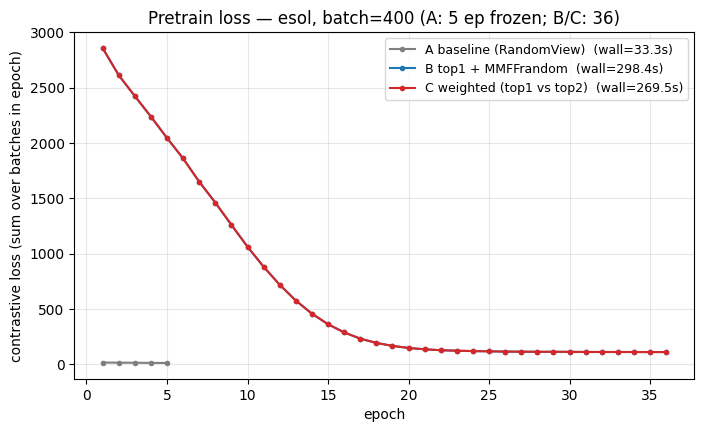

In [7]:
# --- 6. Loss curves ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(max(8.0, 2.6 * len(SIDES)), 4.5))
for side in SIDES:
    r = pre_results.get(side)
    if not r or not r['losses_per_epoch']:
        continue
    ys = r['losses_per_epoch']
    ax.plot(range(1, len(ys) + 1), ys, marker='o', markersize=3,
            color=colors[side], label=f"{labels[side]}  (wall={r['wall_s']:.1f}s)")
ax.set_xlabel('epoch')
ax.set_ylabel('contrastive loss (sum over batches in epoch)')
ax.set_title(f'Pretrain loss — {DATASET}, batch={BATCH_SIZE} (A: {q.BASELINE_A_P_EPOCH} ep frozen; B/C: {P_EPOCH})')
ax.grid(alpha=0.3)
ax.legend(loc='best', fontsize=9)
out = RUN_DIR / f'pretrain_loss_{FIG_TS}.png'
fig.savefig(out, dpi=140, bbox_inches='tight')
print('saved:', out)
plt.show()

## 3.5 분자별 MMFF 슬롯 가중치 보기

`WEIGHTS_PT` (예: `dataset/esol_mmff_weights_qdf.pt`) 를 사람이 읽을 수 있는 CSV 로 풀고, 가장 한쪽으로 \"치우친\" (uniform 에서 가장 먼) 분자 상위 10개와 가장 균등한 10개를 표로 보여줍니다.

CLI 로도 가능합니다 (`examples/sslgraph/bench/dump_mmff_weights.py`)::

```bash
python examples/sslgraph/bench/dump_mmff_weights.py \
    --in dataset/esol_mmff_weights_qdf.pt \
    --out dataset/esol_mmff_weights_qdf.csv \
    --sort-by top_minus_uniform
```

In [8]:
# --- 6.5 Per-molecule MMFF slot weight table ------------------------------
import pandas as pd
from IPython.display import display

csv_path = WEIGHTS_PT.with_suffix('.csv')
if not csv_path.is_file() and WEIGHTS_PT.is_file():
    _run([PY, 'examples/sslgraph/bench/dump_mmff_weights.py',
          '--in', WEIGHTS_PT, '--out', csv_path,
          '--sort-by', 'top_minus_uniform'])

if csv_path.is_file():
    df_w = pd.read_csv(csv_path)
    print(f'{csv_path}  ({len(df_w)} 분자)')
    # uniform 으로부터 가장 멀리 떨어진 (= 한 슬롯에 가장 표가 몰리는) 상위 10개
    print('\n[top-skewed] uniform 에서 멀리 떨어진 분자 상위 10개')
    display(df_w.head(10)[['smiles', 'w1', 'w2', 'w3', 'w4', 'top_slot', 'top_minus_uniform', 'entropy_bits']])
    # 가장 균등한 (entropy 가 log2(4)=2 에 가까운) 분자 10개
    print('\n[most-uniform] 가중치가 가장 평평한 분자 10개')
    display(df_w.nlargest(10, 'entropy_bits')[['smiles', 'w1', 'w2', 'w3', 'w4', 'top_slot', 'top_minus_uniform', 'entropy_bits']])
    print('\n전체 분포 요약')
    display(df_w[['w1', 'w2', 'w3', 'w4', 'entropy_bits', 'top_minus_uniform']].describe().T)
else:
    print(f'(skip) {WEIGHTS_PT} 또는 {csv_path} 가 없어 표시할 가중치가 없습니다.')

/home/ubuntu/3DGCL/dataset/esol_mmff_weights_qdf_atomization.csv  (731 분자)

[top-skewed] uniform 에서 멀리 떨어진 분자 상위 10개


,smiles,w1,w2,w3,w4,top_slot,top_minus_uniform,entropy_bits
0,CCC(O)(CC)CC,0.075290,0.770233,0.079756,0.074721,2,0.520233,1.141634
1,CCCOCC,0.078256,0.069407,0.083280,0.769058,4,0.519058,1.144751
2,CCOCC,0.078720,0.768847,0.083596,0.068837,2,0.518847,1.145312
3,CCCCCC(=O)C,0.069895,0.075728,0.768744,0.085633,3,0.518744,1.145550
4,OC(Cn1cncn1)(c2ccc(F)cc2)c3ccccc3F,0.768308,0.078970,0.067790,0.084931,1,0.518308,1.146739
5,CC1CC2C3CCC4=CC(=O)C=CC4(C)C3(F)C(O)CC2(C)C1(O...,0.091348,0.069418,0.072376,0.766857,4,0.516857,1.150406
6,CCCCCC(C)C,0.084103,0.084516,0.064694,0.766687,4,0.516687,1.151079
7,CCCCCCCC,0.094004,0.071795,0.068542,0.765660,4,0.515660,1.153472
8,CCCOC(=O)c1ccc(N)cc1,0.765479,0.078637,0.064486,0.091398,1,0.515479,1.154145
9,CN(C=Nc1ccc(C)cc1C)C=Nc2ccc(C)cc2C,0.093121,0.065695,0.075766,0.765419,4,0.515419,1.154199



[most-uniform] 가중치가 가장 평평한 분자 10개


,smiles,w1,w2,w3,w4,top_slot,top_minus_uniform,entropy_bits
730,Cc1ccc(O)cc1C,0.309753,0.032069,0.343463,0.314715,3,0.093463,1.737332
729,CCOC=C,0.326893,0.297445,0.343575,0.032087,3,0.093575,1.736401
726,O=N(=O)c1cc(cc(c1)N(=O)=O)N(=O)=O,0.307854,0.294006,0.365995,0.032145,3,0.115995,1.732639
725,CCC(O)CC,0.032193,0.278998,0.320647,0.368162,4,0.118162,1.730308
727,O=C1NC(=O)C(=O)N1,0.270200,0.364699,0.332869,0.032232,2,0.114699,1.728803
720,CC34CCC1C(CC=C2CC(O)CCC12C)C3CCC4=O,0.032249,0.278442,0.305585,0.383724,4,0.133724,1.726293
728,CC(=O)N,0.255311,0.032346,0.361320,0.351023,3,0.111320,1.723827
714,CCCOC(=O)CCC,0.032281,0.392157,0.284629,0.290933,2,0.142157,1.723712
710,Cn1ccc(=O)[nH]c1=O,0.276518,0.394710,0.032309,0.296463,2,0.144710,1.722187
708,CC(C)CCOC=O,0.398336,0.274639,0.032334,0.294690,1,0.148336,1.720541



전체 분포 요약


,count,mean,std,min,25%,50%,75%,max
w1,731.0,0.222465,0.215659,0.032193,0.055133,0.119891,0.329390,0.768308
w2,731.0,0.239580,0.216758,0.032069,0.066212,0.143977,0.377327,0.770233
w3,731.0,0.251521,0.216604,0.032309,0.066876,0.165479,0.411474,0.768744
w4,731.0,0.286434,0.240857,0.032087,0.065056,0.203223,0.499717,0.769058
entropy_bits,731.0,1.451184,0.157126,1.141634,1.322453,1.479276,1.566563,1.737332
top_minus_uniform,731.0,0.342042,0.110685,0.093463,0.249084,0.342408,0.441252,0.520233


## 4. Finetune RMSE 비교 (downstream 정확도)

각 측면의 best 체크포인트를 SchNet 인코더에 로드해 ESOL 회귀로 finetune (3-fold scaffold split). 평균 test RMSE ± SD 를 보고합니다.

In [9]:
# --- 7. Finetune each checkpoint -------------------------------------------
# 주의: side 1개당 ESOL(1128분자) × 3-fold × F_EPOCH=30 ≈ 3~4분 (XPU Arc 140V 기준).
# SIDES 개수만큼 곱하면 됩니다. 빠르게 보고 싶으면 cell 1 의 `QUALITY_BUDGET`(`smoke`/`two_hour`) 또는 F_EPOCH 를 줄이세요.
# 이 셀만 재실행하면 됩니다.
# 부분 결과는 **side 가 끝날 때마다 즉시** ``finetune_summary.json`` 으로 저장됩니다.
# 따라서 도중에 Ctrl+C 를 눌러도 직전까지 끝난 측면의 RMSE 는 사라지지 않습니다.
# FINETUNE_BATCH 는 cell 1 의 노브를 사용 (기본 128, finetune.ipynb 기본 32 대비 ~2-3×).

# dig/sslgraph/evaluation/finetune.py 의 k_scaffold 가 ESOL 처럼 작은 데이터셋에서
# 더 견고하게 split 을 잡도록 수정됨 (seed perturbation 폭 확장). 셀만 재실행해도
# 새 코드가 반영되도록 명시적으로 reload — kernel restart 불필요.
import importlib
import dig.sslgraph.evaluation.finetune as _ft_mod
importlib.reload(_ft_mod)
import dig.sslgraph.evaluation as _ev_mod
importlib.reload(_ev_mod)
importlib.reload(q)  # pretrain_quality_core 도 새 Finetune 을 참조하도록

summary_path = RUN_DIR / 'finetune_summary.json'
if summary_path.is_file():
    try:
        fine_results = json.loads(summary_path.read_text(encoding='utf-8'))
        print(f'[resume] {summary_path} 에서 {sorted(fine_results.keys())} 측면 결과 발견 — 건너뜁니다.')
    except Exception:
        fine_results = {}
else:
    fine_results = {}

est_bc_s = max(F_EPOCH, 1) * N_FOLDS * N_TIMES * 2.6  # B/C, 대략 XPU
est_a_s = max(q.BASELINE_A_F_EPOCH, 1) * q.BASELINE_A_N_FOLDS * q.BASELINE_A_N_TIMES * 2.6
_n_sides = len(SIDES)
_n_bc = sum(1 for s in SIDES if s != 'A')
_est_sum = est_a_s * (1 if 'A' in SIDES else 0) + est_bc_s * _n_bc
print(f'[plan] finetune: A 고정 f={q.BASELINE_A_F_EPOCH}×folds={q.BASELINE_A_N_FOLDS}×t={q.BASELINE_A_N_TIMES} (~{est_a_s:.0f}s/측면), '
      f'B/C 는 f={F_EPOCH}×{N_FOLDS}×{N_TIMES} (~{est_bc_s:.0f}s/측면)  (XPU 대략)')
print(f'[plan] SIDES={SIDES} → finetune 합산(잠정) ≈ {_est_sum/60:.1f}분')

try:
    for side in SIDES:
        if side in fine_results and fine_results[side].get('rmse_mean') is not None:
            r = fine_results[side]
            print(f'\n===== finetune side {side} (cached) =====')
            print(f"  RMSE = {r['rmse_mean']:.4f} ± {r['rmse_sd']:.4f}")
            continue
        _ts = time.strftime("%H:%M:%S")
        print(f'\n===== finetune side {side} (start at {_ts}) =====')
        t_side = time.perf_counter()
        r = q.run_finetune_side(
            pre_results[side],
            dataset=DATASET, batch_size=FINETUNE_BATCH,
            f_epoch=F_EPOCH, n_times=N_TIMES, n_folds=N_FOLDS,
            device=DEVICE,
            esol_filter_qm78=ESOL_FILTER_QM78,
            dataset_root=DATASET_ROOT,
            test_max_atoms=(ESOL_TEST_MAX_ATOMS if DATASET == 'esol' else None),
        )
        fine_results[side] = r
        if r.get('rmse_mean') is not None:
            print(f"  RMSE = {r['rmse_mean']:.4f} ± {r['rmse_sd']:.4f}  "
                  f"(wall={r['wall_s']:.1f}s, elapsed={time.perf_counter()-t_side:.1f}s)")
        else:
            print('  finetune skipped/failed:', r.get('error'))
        # 즉시 저장 — Ctrl+C 안전
        with open(summary_path, 'w', encoding='utf-8') as f:
            json.dump(fine_results, f, indent=2, default=str)
        print(f'  [saved] {summary_path}')
        gc.collect()
        if hasattr(torch, 'xpu'):
            try: torch.xpu.empty_cache()
            except Exception: pass
except KeyboardInterrupt:
    print('\n[interrupted] 도중에 중단됨. 직전까지 끝난 측면의 결과는 보존됩니다:',
          {k: (v.get('rmse_mean'), v.get('rmse_sd')) for k, v in fine_results.items()})
    print(f'재개하려면 이 셀을 다시 실행 — {summary_path} 의 캐시를 자동으로 사용합니다.')

print('\nsaved:', summary_path, '   sides done:', sorted(fine_results.keys()))

[plan] finetune: A 고정 f=18×folds=2×t=1 (~94s/측면), B/C 는 f=80×3×2 (~1248s/측면)  (XPU 대략)
[plan] SIDES=('A', 'B', 'C') → finetune 합산(잠정) ≈ 43.2분

===== finetune side A (start at 07:39:45) =====
[k_scaffold] preparing fold 1/2 (scaffold split over 1128 molecules)...


/home/ubuntu/3DGCL/dig/sslgraph/evaluation/finetune.py:294: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. The given 'InMemoryDataset' only references a subset of examples of the full dataset, but 'data' will contain information of the full dataset. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  self.dataset.data.y = self.dataset.data[self.target]


[k_scaffold] test subset: total_atoms≤14 (RDKit AddHs+GetNumAtoms) → 10/121 molecules


/home/ubuntu/3DGCL/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


895 112 10


...

[k_scaffold] test subset: total_atoms≤14 (RDKit AddHs+GetNumAtoms) → 0/0 molecules
[k_scaffold] fold 3 split rejected (train=1034, val=94, test=0; need val>22 and test>0); retrying with perturbed seed [1/100]
[k_scaffold] preparing fold 3/3 (retry 1) (scaffold split over 1128 molecules)...
[k_scaffold] test subset: total_atoms≤14 (RDKit AddHs+GetNumAtoms) → 1/44 molecules


/home/ubuntu/3DGCL/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


980 104 1


Finetune: epoch 80: 100%|██████████| 80/80 [02:56<00:00,  2.20s/it, FOLD=3.0, best_test_loss=2.020, best_val_loss=1.249, test_rmse=2.013, train_rmse=nan, val_rmse=1.250]


  RMSE = 1.6692 ± 0.4094  (wall=868.8s, elapsed=869.1s)
  [saved] /home/ubuntu/3DGCL/examples/sslgraph/bench/figs/pretrain_quality_0514_0729/finetune_summary.json

saved: /home/ubuntu/3DGCL/examples/sslgraph/bench/figs/pretrain_quality_0514_0729/finetune_summary.json    sides done: ['A', 'B', 'C']


saved: /home/ubuntu/3DGCL/examples/sslgraph/bench/figs/pretrain_quality_0514_0729/finetune_rmse_0514_0729.png


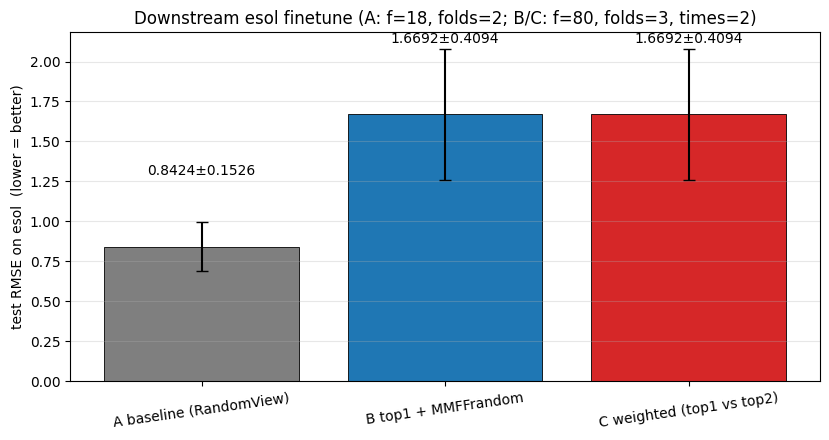

In [10]:
# --- 8. RMSE bar chart -----------------------------------------------------
fig, ax = plt.subplots(figsize=(max(7.0, 2.8 * len(SIDES)), 4.5))
xs, ys, errs, txts, bar_colors = [], [], [], [], []
for side in SIDES:
    r = fine_results.get(side, {})
    m = r.get('rmse_mean')
    if m is None or np.isnan(m):
        continue
    xs.append(labels[side])
    ys.append(m)
    errs.append(r.get('rmse_sd') or 0.0)
    # 4 decimals: .3f bar labels made distinct runs look identical at 0.001 scale.
    txts.append(f"{m:.4f}±{r.get('rmse_sd', 0.0):.4f}")
    bar_colors.append(colors[side])
bars = ax.bar(xs, ys, yerr=errs, capsize=4,
              color=bar_colors,
              edgecolor='black', linewidth=0.6)
ax.set_ylabel(f'test RMSE on {DATASET}  (lower = better)')
ax.set_title(f'Downstream {DATASET} finetune (A: f={q.BASELINE_A_F_EPOCH}, folds={q.BASELINE_A_N_FOLDS}; B/C: f={F_EPOCH}, folds={N_FOLDS}, times={N_TIMES})')
ax.grid(axis='y', alpha=0.3)
for bar, txt in zip(bars, txts):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(errs or [0]) * 1.05 + 1e-3,
            txt, ha='center', va='bottom', fontsize=10)
for lbl in ax.get_xticklabels():
    lbl.set_rotation(8)
out = RUN_DIR / f'finetune_rmse_{FIG_TS}.png'
plt.tight_layout()
fig.savefig(out, dpi=140, bbox_inches='tight')
print('saved:', out)
plt.show()

In [11]:
# --- 9. Combined summary table ---------------------------------------------
import pandas as pd
rows = []
for side in SIDES:
    pr = pre_results.get(side, {})
    fr = fine_results.get(side, {})
    dr = dist_results.get(side, {})
    rows.append({
        'side': side,
        'label': labels[side],
        'view': ','.join(pr.get('view_classes', [])),
        'pretrain_wall_s': pr.get('wall_s'),
        'pretrain_last_loss': (pr.get('losses_per_epoch') or [None])[-1],
        'rmse_mean': fr.get('rmse_mean'),
        'rmse_sd': fr.get('rmse_sd'),
        'finetune_wall_s': fr.get('wall_s'),
        'slots_used': dr.get('n_slots_used'),
        'kl_to_uniform_bits': dr.get('kl_to_uniform_bits'),
        'per_graph_entropy_bits_mean': dr.get('per_graph_entropy_bits_mean'),
    })
df = pd.DataFrame(rows)
df.to_csv(RUN_DIR / 'summary.csv', index=False)
print('saved:', RUN_DIR / 'summary.csv')
df

saved: /home/ubuntu/3DGCL/examples/sslgraph/bench/figs/pretrain_quality_0514_0729/summary.csv


,side,label,view,pretrain_wall_s,pretrain_last_loss,rmse_mean,rmse_sd,finetune_wall_s,slots_used,kl_to_uniform_bits,per_graph_entropy_bits_mean
0,A,A baseline (RandomView),"RandomView,RandomView",33.327223,12.986761,0.842355,0.152551,69.062855,3,0.496541,1.481593
1,B,B top1 + MMFFrandom,"WeightedMMFFView,RandomView",298.437463,111.739006,1.669195,0.409442,853.547168,4,0.216352,1.136358
2,C,C weighted (top1 vs top2),"WeightedMMFFView,WeightedMMFFView",269.517991,111.739006,1.669195,0.409443,868.782146,4,0.054789,1.000000


## 노트

1. **시간 예산**
   - 기본 `QUALITY_BUDGET='two_hour'` (~2h 목표, 가중치·ESOL 캐시·GPU/XPU 가정).
   - `QUALITY_BUDGET='smoke'` 또는 `QUALITY_SMOKE=True` 로 GPU/XPU 기준 전체 ~5분 전후(환경에 따라 다름).
   - 최대 정확도: `QUALITY_BUDGET='max_accuracy'` (야간급).
   - 수동: 셀 1 에서 `P_EPOCH`/`F_EPOCH`/`N_TIMES`/`N_FOLDS` 는 budget 분기 **안**에서만 바꾸거나, 분기 뒤에 재대입.
2. **재현성**
   - 모든 셀이 `seed=2222` 사용. `MMFFRANDOM_FAST` / `MMFFRANDOM_WEIGHTED` 환경변수는 `pretrain_quality_core` 내부의 `_clean_aug_env()` 가 자동으로 마스킹.
   - 호스트 환경 변수는 셀 종료 후 원상복귀 (non-destructive).
3. **체크포인트**
   - `./models/quality_<MMDD_HHMM>/{A,B,C}/...` 에 각각 별도 저장. 같은 시간대에 여러 번 돌리면 폴더 이름의 분 단위 timestamp 가 달라지면서 자동 분리.
4. **`C` 가 `A` 보다 RMSE 가 낮지 않다면**
   - `WEIGHT_KT` 를 0.1~0.5 로 줄여 분포를 더 첨예하게.
   - `QDF_PROPERTY` 를 `atomization` 으로 (homolumo 는 conformer 간 spread 가 매우 작음).
   - `compute_mmff_weights.py` 메타데이터 (`meta['qdf_property']`, `meta['normalize']`) 가 의도대로인지 확인.
   - epoch 을 늘려서 학습 신호를 더 받게.

5. **Finetune 시간**
   - side 개수는 `len(SIDES)` (`SIDES_SELECTION` 이 정한 부분집합). 시간은 대략 측면 1개당 비용 × `len(SIDES)`.
   - 더 빠르게: 셀 1 `smoke` 분기에서 `P_EPOCH`·`F_EPOCH`·`DIST_N_CALLS` 를 줄이거나 `N_FOLDS`·`N_TIMES` 를 낮추세요.
   - 더 정확하게: `QUALITY_BUDGET='max_accuracy'` 또는 `N_TIMES`·`N_FOLDS`·`F_EPOCH` 증가.
   - `FINETUNE_BATCH` 를 256/512 로 더 키워도 됨 (z_dim=32, SchNet 가벼움); ESOL 1128 분자라 batch=512 면 train_loader 가 fold 당 2 batch.

6. **B 측면**
   - **B**: `MMFFweighted_top1` + `MMFFrandom` → view1 은 `.pt` 가중치 **argmax** 슬롯, view2 는 **균등 랜덤** MMFF 슬롯 쌍(RandomView 경로).
   - 속도/커널만 보려면 `compare_pretrain_ab.py` 를 사용.